In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
table = pd.read_csv("examples/pre10_genus.tsv", sep='\t', index_col=0)
meta = pd.read_csv("examples/final_italy_mmi.tsv", sep='\t').set_index("#SampleID")

In [3]:
meta = meta[meta["Host_disease"] == "Control"].copy()

table = table.loc[meta.index]

In [4]:
from ancombc_viz.simple_name import extract_p_g_or_f
from ancombc_viz.ancombc import Analyzer
from ancombc_viz.plotting import plot_group_bar

top30_short_names = {
    col: extract_p_g_or_f(col)
    for col in table.columns
}

anc = Analyzer()
anc.set_feature_table(table)
anc.set_metadata(meta, formula="Group")
sig = anc.ancombc_analysis(feature_name_map=top30_short_names)
## ana = Analyzer()
## ana.set_feature_table(ft)
## ana.set_metadata(mt)
## sig = ana.ancombc_analysis()

sig


/home/pss8993/repo/ancombcviz/ancombc_viz/ancombc.py:34: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  self.ancombc_signif = (self.results.query('Covariate != "Intercept" & Signif == True').round(3).reset_index().copy())


,FeatureID,Covariate,Log2(FC),SE,W,pvalue,qvalue,Signif
0,p__Bacillota_A_368345;g__Eubacterium_G_180878,Group[T.mmilow],-0.927,0.247,-3.754,0.0,0.032,True
1,p__Bacillota_A_368345;g__Ruminococcus_B,Group[T.mmilow],1.420,0.372,3.815,0.0,0.025,True
2,p__Actinomycetota;g__Eggerthella,Group[T.mmilow],1.987,0.371,5.361,0.0,0.000,True
3,p__Bacillota_A_368345;g__Hominicoprocola,Group[T.mmilow],-1.442,0.319,-4.525,0.0,0.001,True
4,p__Bacillota_A_368345,Group[T.mmilow],-0.661,0.137,-4.821,0.0,0.000,True
5,p__Bacillota_A_368345;g__Lawsonibacter,Group[T.mmilow],-0.763,0.204,-3.736,0.0,0.034,True
6,p__Bacillota_A_368345;g__Dysosmobacter,Group[T.mmilow],-1.102,0.293,-3.765,0.0,0.031,True
7,p__Bacteroidota;g__Alistipes_A_871404,Group[T.mmilow],-1.487,0.255,-5.839,0.0,0.000,True
8,p__Bacillota_A_368345;g__Anaerotruncus,Group[T.mmilow],-0.615,0.162,-3.797,0.0,0.027,True
9,p__Bacillota_A_368345;g__Terrisporobacter,Group[T.mmilow],1.163,0.297,3.916,0.0,0.017,True


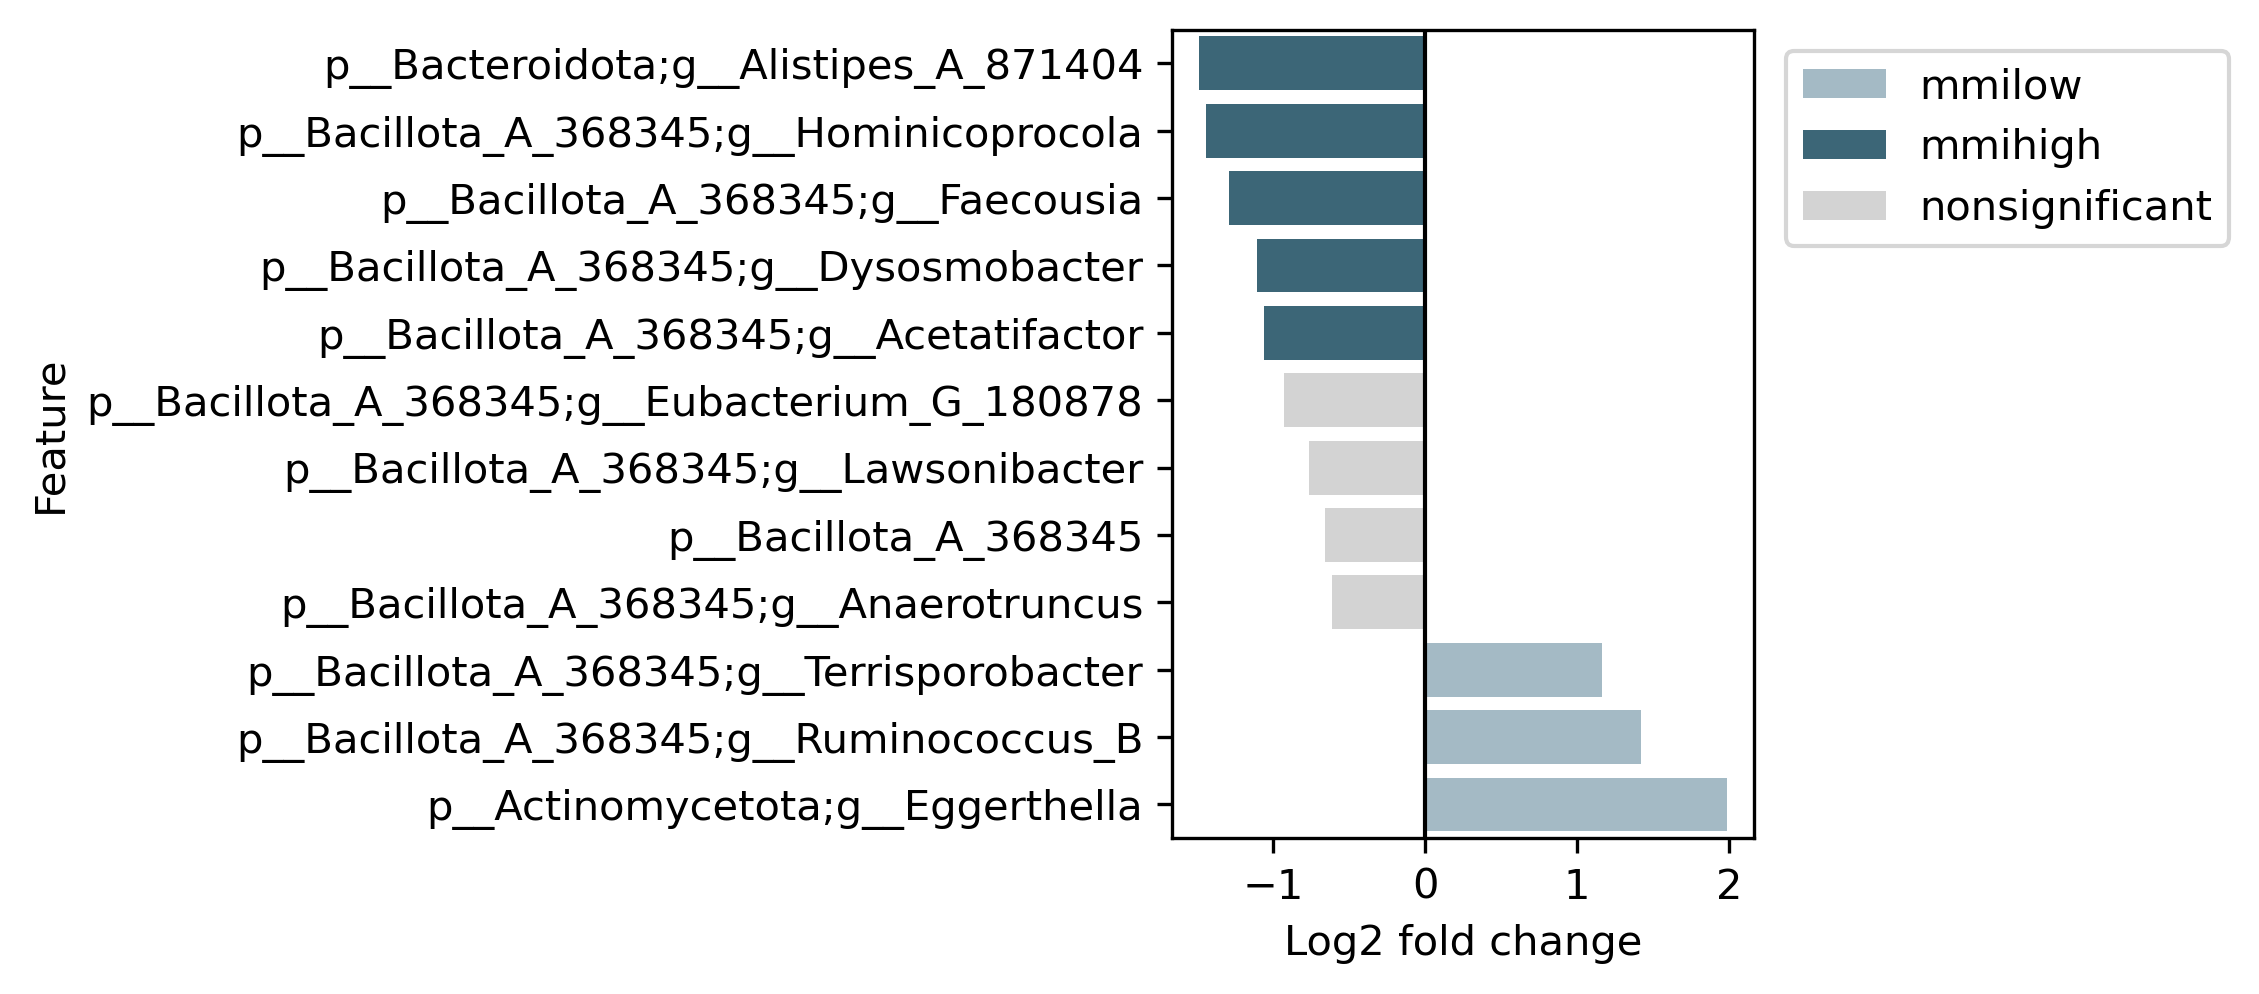

In [5]:
plot_group_bar(sig, group="mmilow", ref_group="mmihigh", top_n=30, fc_cut=1, top_name_map=None, ax=None)